Looking for files in:
  /Users/nicolasanderson/Library/CloudStorage/OneDrive-CaliforniaInstituteofTechnology/Anderson/RockMag/PKQ-A-/PKQ-A-0H
  /Users/nicolasanderson/Library/CloudStorage/OneDrive-CaliforniaInstituteofTechnology/Anderson/RockMag/PKQ-A-/PKQ-A-2M
  /Users/nicolasanderson/Library/CloudStorage/OneDrive-CaliforniaInstituteofTechnology/Anderson/RockMag/PKQ-A-/PKQ-A-3H
  ...

Processing PKQ-A-0H...
  ✓ Plotted 23 demagnetization steps
    NRM: Dec=48.4°, Inc=177.7°
    Final: Dec=246.0°, Inc=77.2°
Processing PKQ-A-2M...
  ✓ Plotted 24 demagnetization steps
    NRM: Dec=63.6°, Inc=307.3°
    Final: Dec=288.9°, Inc=61.3°
Processing PKQ-A-3H...
  ✓ Plotted 23 demagnetization steps
    NRM: Dec=76.8°, Inc=325.4°
    Final: Dec=316.3°, Inc=78.9°
Processing PKQ-A-6M...
  ✓ Plotted 23 demagnetization steps
    NRM: Dec=-0.7°, Inc=130.1°
    Final: Dec=203.3°, Inc=-30.6°
Processing PKQ-A-9I...
  ✓ Plotted 23 demagnetization steps
    NRM: Dec=48.9°, Inc=168.1°
    Final: Dec=292.3°, 

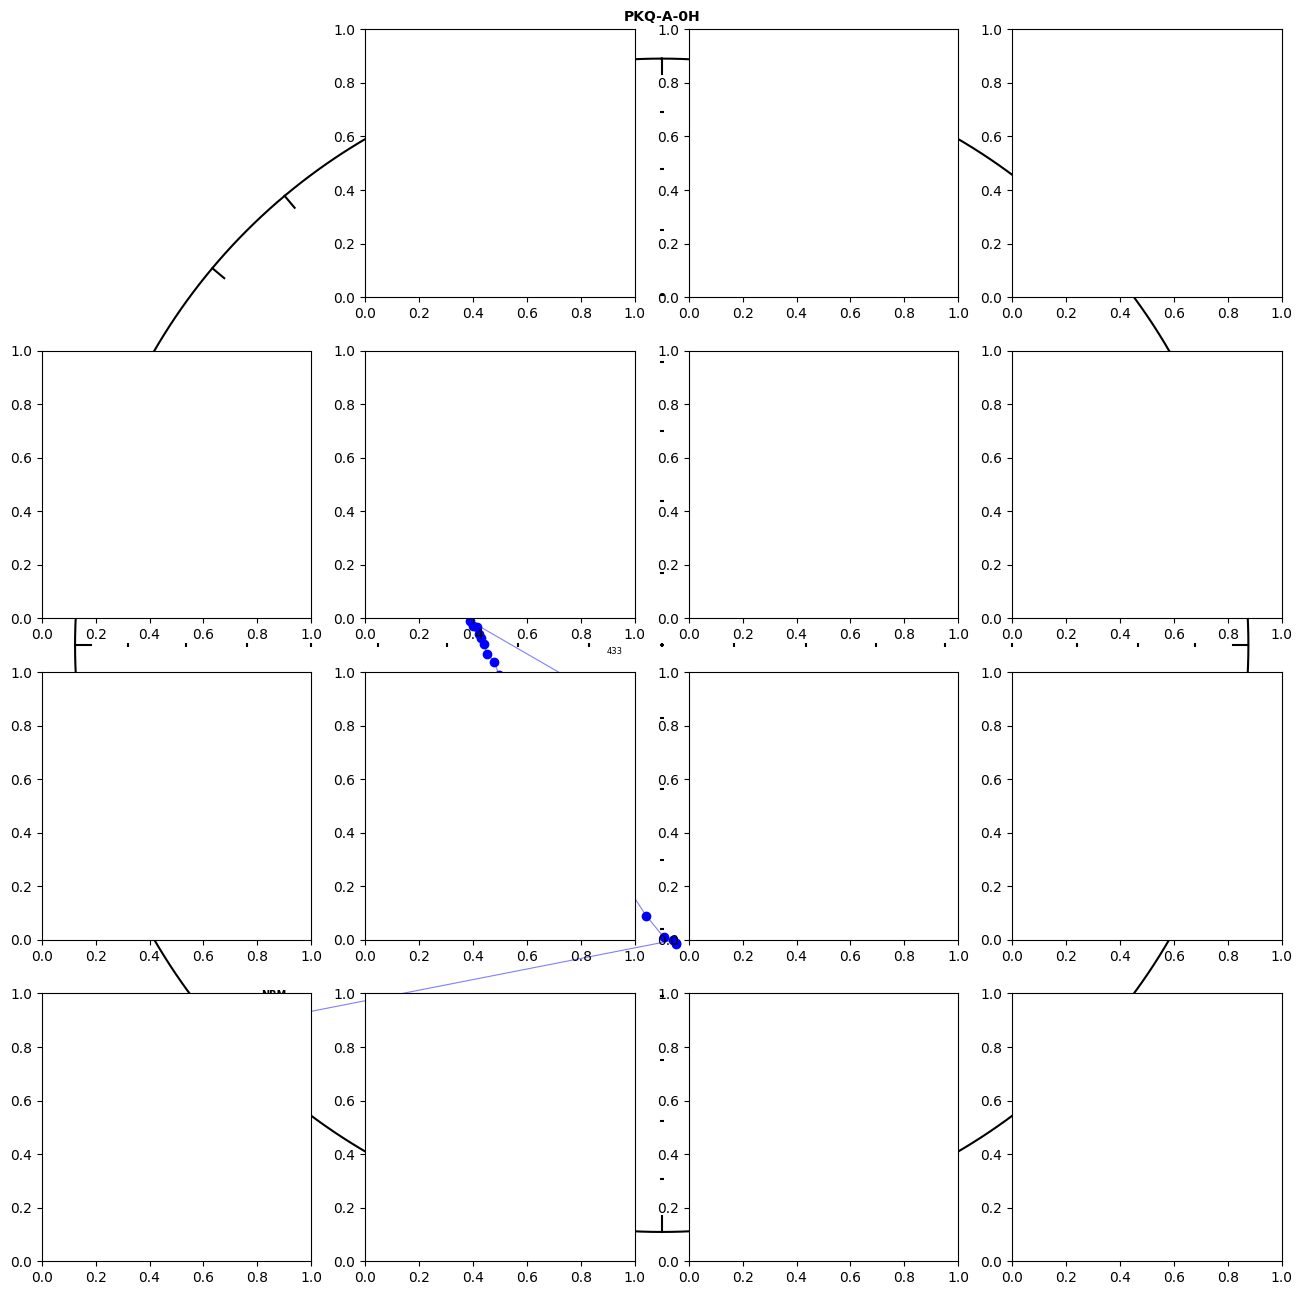

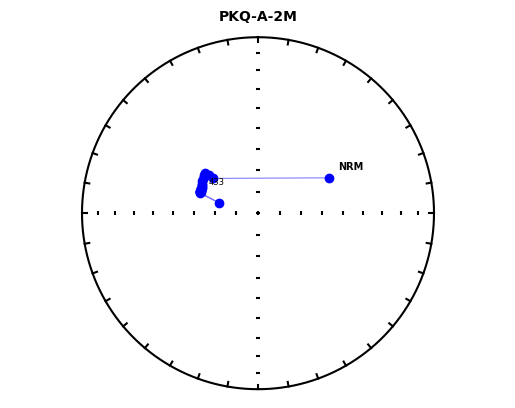

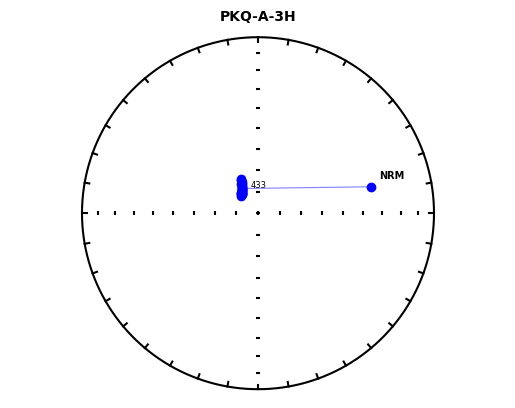

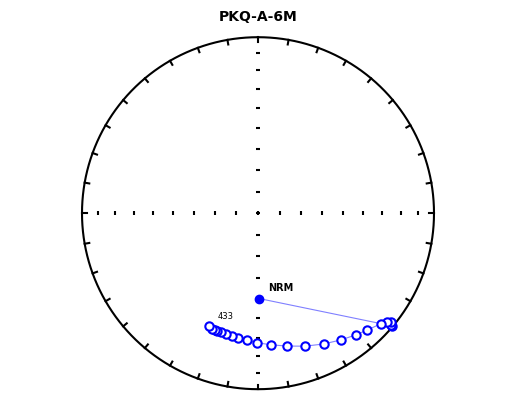

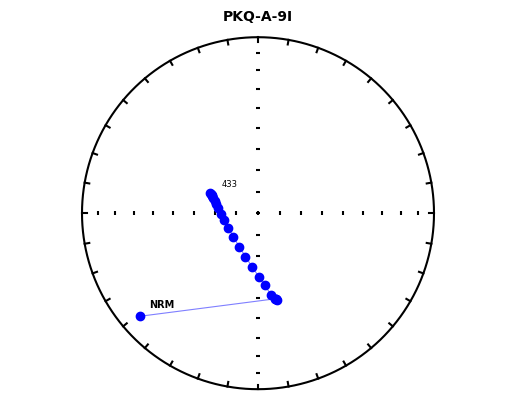

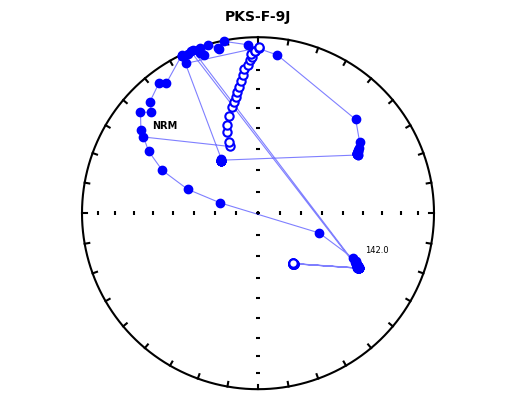

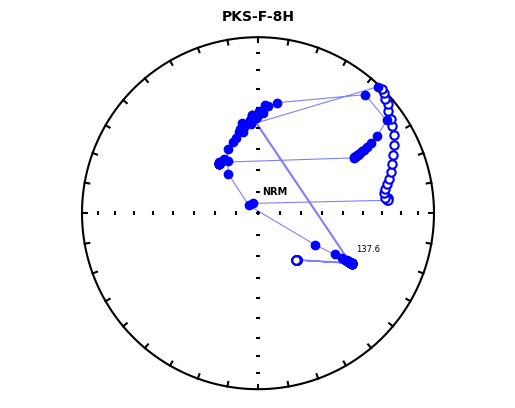

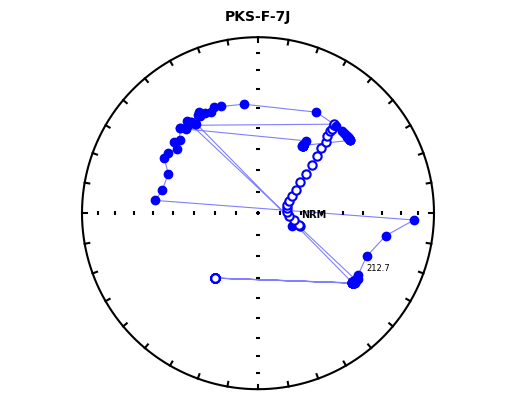

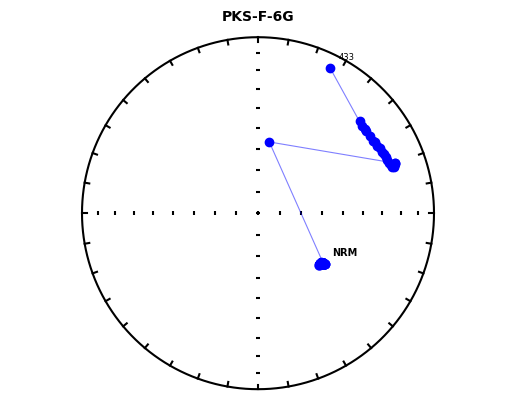

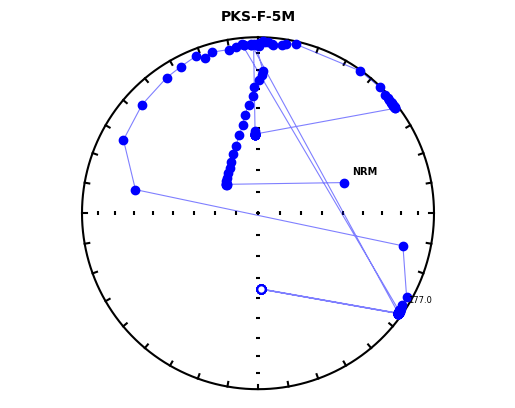

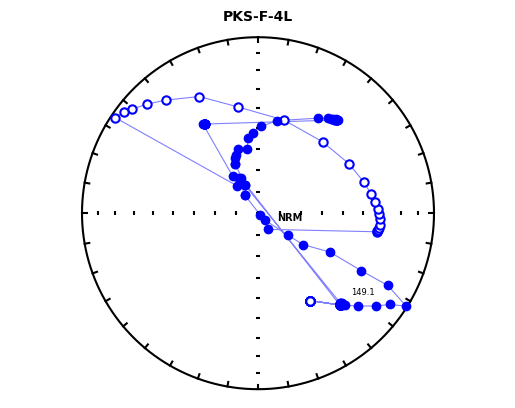

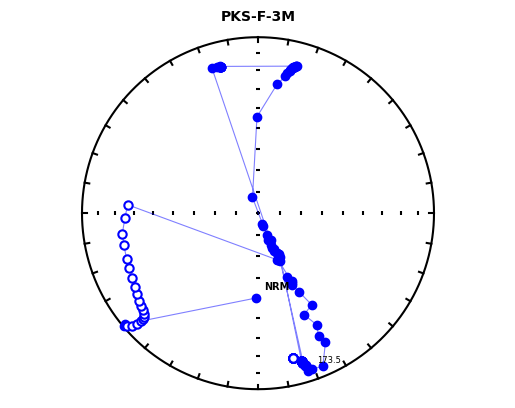

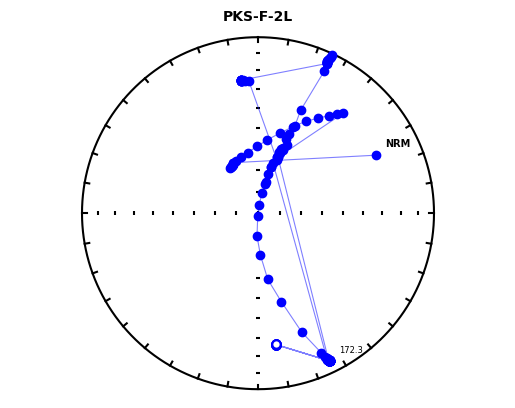

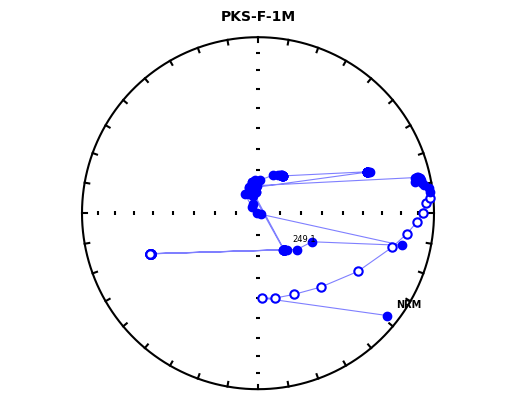

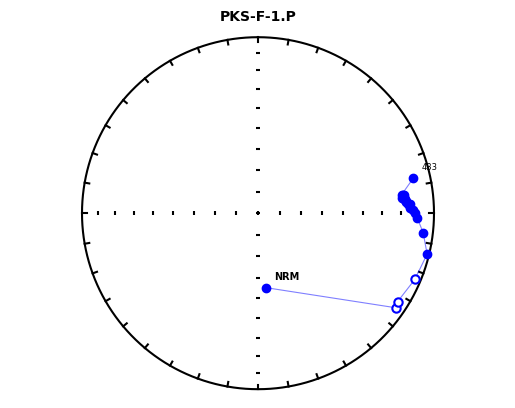

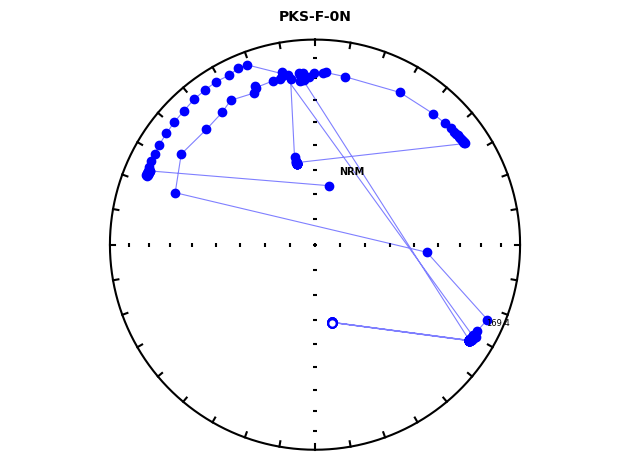

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import os

def parse_af_data(filepath):
    """Parse AF demagnetization data from file"""
    declinations = []
    inclinations = []
    intensities = []
    treatments = []
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
        # Skip the first two lines (header and sample info)
        for line in lines[2:]:
            if line.strip():
                parts = line.split()
                # Extract treatment type and level
                treatment = parts[0]
                if len(parts) > 1 and parts[1].replace('.', '').replace('-','').isdigit():
                    # This is an AF or other treatment with a level (e.g., "AF 16")
                    treatment_level = parts[1]
                    treatments.append(f"{treatment} {treatment_level}")
                    # Declination is in column 2, inclination in column 3
                    dec = float(parts[2])
                    inc = float(parts[3])
                    # Intensity is in column 6 (in scientific notation)
                    intensity = float(parts[6])
                else:
                    # This is NRM (no level number)
                    treatments.append(treatment)
                    # For NRM: dec is column 1, inc is column 2
                    dec = float(parts[1])
                    inc = float(parts[2])
                    # Intensity is in column 5
                    intensity = float(parts[5])
                
                declinations.append(dec)
                inclinations.append(inc)
                intensities.append(intensity)
    
    return declinations, inclinations, intensities, treatments

def plot_stereonet(declinations, inclinations, treatments, sample_name, ax):
    """Plot data on equal area stereonet"""
    
    # Plot each step
    for i, (dec, inc) in enumerate(zip(declinations, inclinations)):
        # Convert to equal area coordinates
        if inc < 0:  # Upper hemisphere - plot as open circles
            xy = pmag.dimap(dec, inc)
            ax.plot(xy[0], xy[1], 'wo', markeredgecolor='blue', markersize=6, 
                   markeredgewidth=1.5, zorder=3)
        else:  # Lower hemisphere - plot as filled circles
            xy = pmag.dimap(dec, inc)
            ax.plot(xy[0], xy[1], 'bo', markersize=6, zorder=3)
        
        # Add labels for first and last points
        if i == 0:
            ax.text(xy[0]+0.05, xy[1]+0.05, 'NRM', fontsize=7, fontweight='bold', zorder=4)
        elif i == len(declinations) - 1:
            ax.text(xy[0]+0.05, xy[1]+0.05, treatments[i].split()[1] if len(treatments[i].split()) > 1 else treatments[i], 
                   fontsize=6, zorder=4)
    
    # Connect the points with a line to show demagnetization path
    xys = [pmag.dimap(dec, inc) for dec, inc in zip(declinations, inclinations)]
    xs = [xy[0] for xy in xys]
    ys = [xy[1] for xy in xys]
    ax.plot(xs, ys, 'b-', linewidth=0.8, alpha=0.5, zorder=2)
    
    # Set title
    ax.set_title(sample_name, fontsize=10, fontweight='bold')
    ax.set_aspect('equal')

# Define base directory - WITH SPACES IN THE PATH
base_dir = '/Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag'

# Define samples (just the suffixes)
pkq_suffixes = ['0H', '2M', '3H', '6M', '9I']
pks_suffixes = ['9J', '8H', '7J', '6G', '5M', '4L', '3M', '2L', '1M', '1.P', '0N']

# Build file paths - files are in: RockMag/PKQ-A-/PKQ-A-0H or RockMag/PKS-F-/PKS-F-9J
all_samples = []
for suffix in pkq_suffixes:
    sample_name = f'PKQ-A-{suffix}'
    filepath = os.path.join(base_dir, 'PKQ-A-', sample_name)
    all_samples.append((sample_name, filepath))

for suffix in pks_suffixes:
    sample_name = f'PKS-F-{suffix}'
    filepath = os.path.join(base_dir, 'PKS-F-', sample_name)
    all_samples.append((sample_name, filepath))

# Print paths for debugging
print("Looking for files in:")
for name, path in all_samples[:3]:
    print(f"  {path}")
print("  ...")
print()

# Calculate grid dimensions
n_samples = len(all_samples)
n_cols = 4
n_rows = int(np.ceil(n_samples / n_cols))

# Create figure with subplots
fig = plt.figure(figsize=(16, n_rows * 4))

# Process each sample
for idx, (sample_name, filepath) in enumerate(all_samples, 1):
    print(f"Processing {sample_name}...")
    
    # Check if file exists
    if not os.path.exists(filepath):
        print(f"  WARNING: File not found: {filepath}")
        continue
    
    try:
        # Parse data
        decs, incs, ints, treats = parse_af_data(filepath)
        
        # Create subplot
        ax = fig.add_subplot(n_rows, n_cols, idx)
        
        # Plot the stereonet
        ipmag.plot_net(idx)
        ax = plt.gca()
        
        # Plot the data
        plot_stereonet(decs, incs, treats, sample_name, ax)
        
        print(f"  ✓ Plotted {len(decs)} demagnetization steps")
        print(f"    NRM: Dec={decs[0]:.1f}°, Inc={incs[0]:.1f}°")
        print(f"    Final: Dec={decs[-1]:.1f}°, Inc={incs[-1]:.1f}°")
        
    except Exception as e:
        print(f"  ERROR processing {sample_name}: {str(e)}")
        continue

# Adjust layout
plt.tight_layout()

# Save figure
output_path = os.path.join(base_dir, 'all_af_stereonets.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ All plots saved to: {output_path}")

# Also save a high-res PDF version
output_pdf = output_path.replace('.png', '.pdf')
plt.savefig(output_pdf, dpi=300, bbox_inches='tight')
print(f"✓ PDF version saved to: {output_pdf}")

plt.show()

Processing samples (AF demagnetization only):

Processing PKQ-A-0H...
  ✓ Plotted 23 AF demagnetization steps
    NRM: Dec=48.4°, Inc=177.7°
    Final AF: Dec=246.0°, Inc=77.2°
    Intensity: 7.00e-01 → 1.38e-03 A/m

Processing PKQ-A-2M...
    Stopped at line 26: reached max_lines
  ✓ Plotted 23 AF demagnetization steps
    NRM: Dec=63.6°, Inc=307.3°
    Final AF: Dec=285.0°, Inc=71.3°
    Intensity: 7.00e-01 → 1.04e-03 A/m

Processing PKQ-A-3H...
  ✓ Plotted 23 AF demagnetization steps
    NRM: Dec=76.8°, Inc=325.4°
    Final AF: Dec=316.3°, Inc=78.9°
    Intensity: 6.00e-01 → 3.78e-03 A/m

Processing PKQ-A-6M...
  ✓ Plotted 23 AF demagnetization steps
    NRM: Dec=-0.7°, Inc=130.1°
    Final AF: Dec=203.3°, Inc=-30.6°
    Intensity: 8.00e-01 → 1.84e-03 A/m

Processing PKQ-A-9I...
  ✓ Plotted 23 AF demagnetization steps
    NRM: Dec=48.9°, Inc=168.1°
    Final AF: Dec=292.3°, Inc=67.2°
    Intensity: 6.00e-01 → 4.48e-03 A/m

Processing PKS-F-9J...
    Stopped at line 25: AFmax0 (non-A

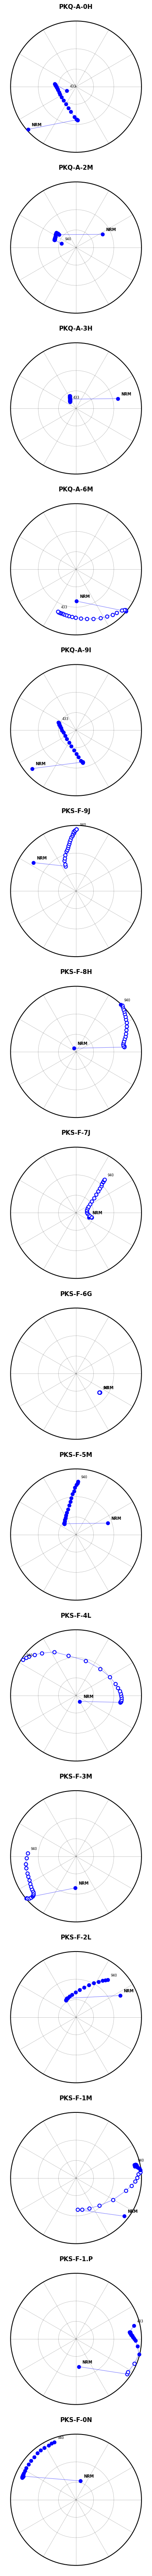

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import os

def parse_af_data(filepath, max_lines=None):
    """Parse AF demagnetization data from file - only AF steps, not AFz/ARM/IRM"""
    declinations = []
    inclinations = []
    intensities = []
    treatments = []
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
        # Skip the first two lines (header and sample info)
        for line_num, line in enumerate(lines[2:], start=3):
            if line.strip():
                parts = line.split()
                treatment = parts[0]
                
                # Stop at AFz, ARM, IRM, or AFmax (not natural remanence)
                if treatment in ['AFz', 'ARM', 'IRM', 'AFmax0', 'IRMz', 'AFzmax0']:
                    print(f"    Stopped at line {line_num}: {treatment} (non-AF treatment)")
                    break
                
                # Also stop if we've reached max_lines
                if max_lines and line_num > max_lines + 1:  # +1 for header offset
                    print(f"    Stopped at line {line_num}: reached max_lines")
                    break
                
                # Parse the data
                if len(parts) > 1 and parts[1].replace('.', '').replace('-','').isdigit():
                    # This is an AF treatment with a level (e.g., "AF 16")
                    treatment_level = parts[1]
                    treatments.append(f"{treatment} {treatment_level}")
                    dec = float(parts[2])
                    inc = float(parts[3])
                    intensity = float(parts[6])
                else:
                    # This is NRM (no level number)
                    treatments.append(treatment)
                    dec = float(parts[1])
                    inc = float(parts[2])
                    intensity = float(parts[5])
                
                declinations.append(dec)
                inclinations.append(inc)
                intensities.append(intensity)
    
    return declinations, inclinations, intensities, treatments

def plot_stereonet(declinations, inclinations, treatments, sample_name, ax):
    """Plot data on equal area stereonet"""
    
    # Manually draw the stereonet circle and grid
    # Draw the outer circle
    circle = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=1.5)
    ax.add_patch(circle)
    
    # Draw grid lines (optional - can be simplified)
    # Small circles every 30 degrees
    for angle in range(0, 360, 30):
        x = np.cos(np.radians(angle))
        y = np.sin(np.radians(angle))
        ax.plot([0, x], [0, y], 'k-', linewidth=0.5, alpha=0.3)
    
    # Draw concentric circles for inclination
    for inc in [30, 60]:
        r = np.tan(np.radians(45 - inc/2))
        circle = plt.Circle((0, 0), r, fill=False, color='black', linewidth=0.5, alpha=0.3)
        ax.add_patch(circle)
    
    # Plot each step
    for i, (dec, inc) in enumerate(zip(declinations, inclinations)):
        # Convert to equal area coordinates
        if inc < 0:  # Upper hemisphere - plot as open circles
            xy = pmag.dimap(dec, inc)
            ax.plot(xy[0], xy[1], 'wo', markeredgecolor='blue', markersize=6, 
                   markeredgewidth=1.5, zorder=3)
        else:  # Lower hemisphere - plot as filled circles
            xy = pmag.dimap(dec, inc)
            ax.plot(xy[0], xy[1], 'bo', markersize=6, zorder=3)
        
        # Add labels for first and last points
        if i == 0:
            ax.text(xy[0]+0.05, xy[1]+0.05, 'NRM', fontsize=7, fontweight='bold', zorder=4)
        elif i == len(declinations) - 1:
            label = treatments[i].split()[1] if len(treatments[i].split()) > 1 else treatments[i]
            ax.text(xy[0]+0.05, xy[1]+0.05, label, fontsize=6, zorder=4)
    
    # Connect the points with a line to show demagnetization path
    xys = [pmag.dimap(dec, inc) for dec, inc in zip(declinations, inclinations)]
    xs = [xy[0] for xy in xys]
    ys = [xy[1] for xy in xys]
    ax.plot(xs, ys, 'b-', linewidth=0.8, alpha=0.5, zorder=2)
    
    # Set title and format axes
    ax.set_title(sample_name, fontsize=11, fontweight='bold', pad=10)
    ax.set_aspect('equal')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.axis('off')  # Hide axes

# Define base directory
base_dir = '/Users/nicolasanderson/Library/CloudStorage/OneDrive-CaliforniaInstituteofTechnology/Anderson/RockMag'

# Define samples (just the suffixes)
pkq_suffixes = ['0H', '2M', '3H', '6M', '9I']
pks_suffixes = ['9J', '8H', '7J', '6G', '5M', '4L', '3M', '2L', '1M', '1.P', '0N']

# Build file paths
all_samples = []
for suffix in pkq_suffixes:
    sample_name = f'PKQ-A-{suffix}'
    filepath = os.path.join(base_dir, 'PKQ-A-', sample_name)
    all_samples.append((sample_name, filepath))

for suffix in pks_suffixes:
    sample_name = f'PKS-F-{suffix}'
    filepath = os.path.join(base_dir, 'PKS-F-', sample_name)
    all_samples.append((sample_name, filepath))

# Create figure - vertical list of subplots (1 column)
n_samples = len(all_samples)
fig, axes = plt.subplots(n_samples, 1, figsize=(6, 4*n_samples))

# If only one sample, axes won't be a list
if n_samples == 1:
    axes = [axes]

print("Processing samples (AF demagnetization only):\n")

# Process each sample
successful_plots = []
for idx, (sample_name, filepath) in enumerate(all_samples):
    print(f"Processing {sample_name}...")
    
    # Check if file exists
    if not os.path.exists(filepath):
        print(f"  WARNING: File not found: {filepath}\n")
        axes[idx].axis('off')
        continue
    
    try:
        # Parse data - only AF steps (typically ~22 lines)
        decs, incs, ints, treats = parse_af_data(filepath, max_lines=24)
        
        if len(decs) == 0:
            print(f"  WARNING: No AF data found\n")
            axes[idx].axis('off')
            continue
        
        # Select the subplot and plot the stereonet
        plot_stereonet(decs, incs, treats, sample_name, axes[idx])
        
        print(f"  ✓ Plotted {len(decs)} AF demagnetization steps")
        print(f"    NRM: Dec={decs[0]:.1f}°, Inc={incs[0]:.1f}°")
        print(f"    Final AF: Dec={decs[-1]:.1f}°, Inc={incs[-1]:.1f}°")
        print(f"    Intensity: {ints[0]:.2e} → {ints[-1]:.2e} A/m\n")
        
        successful_plots.append(sample_name)
        
    except Exception as e:
        print(f"  ERROR processing {sample_name}: {str(e)}\n")
        axes[idx].axis('off')
        continue

# Adjust layout
plt.tight_layout()

# Save figure
output_path = os.path.join(base_dir, 'all_af_stereonets_list.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ All plots saved to: {output_path}")

# Also save PDF version
output_pdf = output_path.replace('.png', '.pdf')
plt.savefig(output_pdf, dpi=300, bbox_inches='tight')
print(f"✓ PDF version saved to: {output_pdf}")

print(f"\nSuccessfully plotted {len(successful_plots)}/{len(all_samples)} samples")

plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pmagpy.pmag as pmag
import os
import re
from collections import defaultdict


# =============================================================================
# CONFIGURATION
# =============================================================================

BASE_DIR = '/Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag'  # Base directory to search for .rmg files
GRID_COLS = 4          # Number of columns per site figure
DPI = 200              # Output resolution
MAX_AF_STEPS = 60      # Safety cap on AF steps to parse per sample

# Treatment labels that mark the end of the AF sequence
# (anything starting with these strings will stop parsing)
STOP_PREFIXES = ('AFz', 'AFmax', 'ARM', 'IRM', 'IRMz', 'TH', 'ThD')

# Column indices in the comma-delimited .rmg format (0-based)
# Row format: Treatment, Level, BiasField, SpinSpeed, HoldTime,
#             Mz, StdDevZ, Mz/Vol, MomSusc,
#             Mx, StdDevX, My, StdDevY, Remarks,
#             CoreDec, CoreInc, M(emu), CSD, Height, DateTime
COL_TREATMENT  = 0
COL_LEVEL      = 1
COL_DEC        = 14
COL_INC        = 15
COL_INTENSITY  = 16   # M (emu) — total moment magnitude

N_HEADER_ROWS  = 4    # Lines 1–4 are header / instrument info


# =============================================================================
# FILE DISCOVERY
# =============================================================================

def find_rmg_files(base_dir):
    """
    Recursively search base_dir for all .rmg files.
    Returns a dict: { site_name: [(sample_name, filepath), ...] }
    Site name is inferred from the parent folder name.
    """
    sites = defaultdict(list)

    for root, dirs, files in os.walk(base_dir):
        dirs.sort()
        files.sort()

        for fname in files:
            if fname.lower().endswith('.rmg'):
                filepath = os.path.join(root, fname)
                sample_name = os.path.splitext(fname)[0]

                # Use the immediate parent folder as the site identifier;
                # fall back to extracting the prefix before the last '-'
                parent = os.path.basename(root).strip()
                if parent and parent != os.path.basename(base_dir):
                    site_name = parent
                else:
                    parts = sample_name.rsplit('-', 1)
                    site_name = parts[0] if len(parts) == 2 else sample_name

                sites[site_name].append((sample_name, filepath))

    return dict(sorted(sites.items()))


# =============================================================================
# DATA PARSING
# =============================================================================

def parse_af_data(filepath, max_steps=MAX_AF_STEPS):
    """
    Parse AF demagnetization steps from a 2G .rmg file.

    File format (comma-delimited):
      Row 1  : sample name + volume
      Row 2  : column headers
      Row 3  : instrument info (treated as header)
      Row 4  : duplicate instrument/time row (treated as header)
      Row 5+ : data rows — NRM first, then AF steps, then AFz/ARM/IRM...

    Columns of interest (0-based):
      0  = Treatment  (NRM / AF / AFz / ARM / IRM …)
      1  = Level      (mT, 0 for NRM)
      14 = Core Dec
      15 = Core Inc
      16 = M (emu)    — total moment magnitude

    Returns: (declinations, inclinations, intensities, treatment_labels)
    """
    declinations, inclinations, intensities, treatments = [], [], [], []

    with open(filepath, 'r') as f:
        lines = f.readlines()

    step_count = 0
    for line_num, line in enumerate(lines):
        if line_num < N_HEADER_ROWS:
            continue  # skip header rows

        line = line.strip()
        if not line:
            continue

        # Split on commas; strip whitespace from each field
        parts = [p.strip() for p in line.split(',')]
        if len(parts) <= COL_INTENSITY:
            continue  # not enough columns

        treatment = parts[COL_TREATMENT]

        # Stop at non-AF treatments
        if any(treatment.startswith(prefix) for prefix in STOP_PREFIXES):
            break

        # Safety cap
        if step_count >= max_steps:
            break

        try:
            level = parts[COL_LEVEL].strip()
            dec   = float(parts[COL_DEC])
            inc   = float(parts[COL_INC])
            mag   = abs(float(parts[COL_INTENSITY]))  # emu, always positive
        except (ValueError, IndexError):
            continue

        label = treatment if treatment == 'NRM' else f"AF {level}"
        declinations.append(dec)
        inclinations.append(inc)
        intensities.append(mag)
        treatments.append(label)
        step_count += 1

    return declinations, inclinations, intensities, treatments


# =============================================================================
# STEREONET PLOTTING (single panel)
# =============================================================================

def _equal_area_xy(dec, inc):
    """Convert dec/inc to equal-area (Schmidt) projection coordinates."""
    return pmag.dimap(dec, inc)


def plot_stereonet(ax, declinations, inclinations, intensities, treatments, sample_name):
    """Draw a single equal-area stereonet panel on *ax*."""

    # --- Background: outer circle + grid ---
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='k', lw=1.5))
    for az in range(0, 360, 30):
        ax.plot([0, np.cos(np.radians(az))], [0, np.sin(np.radians(az))],
                'k-', lw=0.4, alpha=0.25)
    for inc_grid in [30, 60]:
        r = np.tan(np.radians(45 - inc_grid / 2))
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color='k', lw=0.4, alpha=0.25))

    if not declinations:
        ax.set_title(f"{sample_name}\n(no data)", fontsize=8, color='grey')
        ax.set_aspect('equal')
        ax.set_xlim(-1.15, 1.15)
        ax.set_ylim(-1.15, 1.15)
        ax.axis('off')
        return

    # --- Path connecting steps ---
    xys = [_equal_area_xy(d, i) for d, i in zip(declinations, inclinations)]
    ax.plot([xy[0] for xy in xys], [xy[1] for xy in xys],
            '-', color='royalblue', lw=0.8, alpha=0.55, zorder=2)

    # --- Plot each step ---
    for k, (dec, inc, xy) in enumerate(zip(declinations, inclinations, xys)):
        upper = inc < 0
        marker_kw = dict(
            marker='o',
            markersize=5,
            zorder=3,
            markerfacecolor='white' if upper else 'royalblue',
            markeredgecolor='royalblue',
            markeredgewidth=1.2,
        )
        ax.plot(xy[0], xy[1], **marker_kw)

        # Label NRM and final step
        if k == 0:
            ax.annotate('NRM', xy=(xy[0], xy[1]),
                        xytext=(4, 4), textcoords='offset points',
                        fontsize=6, fontweight='bold', color='k', zorder=5)
        elif k == len(declinations) - 1:
            lbl = treatments[k].split()[-1]  # just the mT value
            ax.annotate(lbl, xy=(xy[0], xy[1]),
                        xytext=(4, 4), textcoords='offset points',
                        fontsize=6, color='dimgrey', zorder=5)

    # --- Intensity decay annotation ---
    i0, i_final = intensities[0], intensities[-1]
    pct = (1 - i_final / i0) * 100 if i0 > 0 else 0
    ax.text(0, -1.10, f"{i0:.1e} → {i_final:.1e} A/m  ({pct:.0f}% demag)",
            ha='center', va='top', fontsize=5.5, color='dimgrey', transform=ax.transData)

    # --- Title ---
    ax.set_title(sample_name, fontsize=8, fontweight='bold', pad=4)
    ax.set_aspect('equal')
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.20, 1.15)
    ax.axis('off')


# =============================================================================
# SITE FIGURE BUILDER
# =============================================================================

def plot_site(site_name, samples, output_dir, cols=GRID_COLS):
    """
    Create and save one figure (PNG + PDF) for all samples in a site.
    *samples* is a list of (sample_name, filepath) tuples.
    """
    n = len(samples)
    rows = int(np.ceil(n / cols))
    panel_size = 3.2  # inches per panel

    fig = plt.figure(figsize=(cols * panel_size, rows * panel_size + 0.6))
    fig.suptitle(f"Site: {site_name}  —  AF Demagnetization Stereonets",
                 fontsize=12, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(rows, cols, figure=fig, hspace=0.45, wspace=0.15)

    n_ok = 0
    for idx, (sample_name, filepath) in enumerate(samples):
        row, col = divmod(idx, cols)
        ax = fig.add_subplot(gs[row, col])

        if not os.path.exists(filepath):
            print(f"  [MISSING]  {filepath}")
            ax.text(0.5, 0.5, 'File not\nfound', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='red')
            ax.axis('off')
            continue

        try:
            decs, incs, ints, treats = parse_af_data(filepath)
            plot_stereonet(ax, decs, incs, ints, treats, sample_name)
            if decs:
                n_ok += 1
                print(f"  ✓  {sample_name:20s}  n={len(decs):2d} steps  "
                      f"NRM Dec={decs[0]:.1f}° Inc={incs[0]:.1f}°  "
                      f"Int {ints[0]:.1e}→{ints[-1]:.1e} A/m")
            else:
                print(f"  –  {sample_name}: no AF steps found")
        except Exception as exc:
            print(f"  [ERROR]    {sample_name}: {exc}")
            ax.text(0.5, 0.5, 'Parse\nerror', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='red')
            ax.axis('off')

    # Hide any unused panels
    for idx in range(n, rows * cols):
        row, col = divmod(idx, cols)
        fig.add_subplot(gs[row, col]).axis('off')

    # Save
    safe_name = re.sub(r'[^\w\-]', '_', site_name)
    png_path = os.path.join(output_dir, f"{safe_name}_af_stereonets.png")
    pdf_path = os.path.join(output_dir, f"{safe_name}_af_stereonets.pdf")

    fig.savefig(png_path, dpi=DPI, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    plt.close(fig)

    print(f"  → saved: {png_path}")
    print(f"  → saved: {pdf_path}\n")
    return n_ok


# =============================================================================
# MAIN
# =============================================================================

def main():
    output_dir = os.path.join(BASE_DIR, 'af_stereonet_output')
    os.makedirs(output_dir, exist_ok=True)

    print(f"Searching for .rmg files in:\n  {BASE_DIR}\n")
    sites = find_rmg_files(BASE_DIR)

    if not sites:
        print("No .rmg files found. Check BASE_DIR and file extensions.")
        return

    total_samples = sum(len(v) for v in sites.values())
    print(f"Found {total_samples} samples across {len(sites)} site(s):\n")
    for site, samps in sites.items():
        print(f"  {site}: {len(samps)} sample(s)")
    print()

    total_ok = 0
    for site_name, samples in sites.items():
        print(f"{'='*60}")
        print(f"Site: {site_name}  ({len(samples)} samples)")
        print(f"{'='*60}")
        total_ok += plot_site(site_name, samples, output_dir)

    print(f"\nDone — successfully plotted {total_ok}/{total_samples} samples.")
    print(f"Output directory: {output_dir}")


if __name__ == '__main__':
    main()

Searching for .rmg files in:
  /Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag

Found 14 samples across 9 site(s):

  NWF-A-: 1 sample(s)
  NWF-B-: 1 sample(s)
  NWF-C-: 1 sample(s)
  PKQ-A-: 5 sample(s)
  PKS-: 1 sample(s)
  PKS-F-: 2 sample(s)
  PKS-G-: 1 sample(s)
  PKS-H-: 1 sample(s)
  WBE-A-: 1 sample(s)

Site: NWF-A-  (1 samples)
  ✓  NWF-A-2E              n=22 steps  NRM Dec=151.2° Inc=-7.5°  Int 3.2e-03→3.8e-08 A/m
  → saved: /Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag/af_stereonet_output/NWF-A-_af_stereonets.png
  → saved: /Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag/af_stereonet_output/NWF-A-_af_stereonets.pdf

Site: NWF-B-  (1 samples)
  ✓  NWF-B-3I              n=28 steps  NRM Dec=0.0° Inc=0.0°  Int 0.0e+00→7.3e-04 A/m
  → saved: /Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag/af_stereonet_output/NWF-B-_af_stereonets.png
  → saved: /Users/n

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pmagpy.pmag as pmag
import os
import re
from collections import defaultdict


# =============================================================================
# CONFIGURATION
# =============================================================================

BASE_DIR = '/Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag'  # Base directory to search for .rmg files
GRID_COLS = 4          # Number of columns per site figure
DPI = 200              # Output resolution
MAX_AF_STEPS = 60      # Safety cap on AF steps to parse per sample

# Treatment labels that mark the end of the AF sequence
# (anything starting with these strings will stop parsing)
STOP_PREFIXES = ('AFz', 'AFmax', 'ARM', 'IRM', 'IRMz', 'TH', 'ThD')

# Column indices in the comma-delimited .rmg format (0-based)
# Row format: Treatment, Level, BiasField, SpinSpeed, HoldTime,
#             Mz, StdDevZ, Mz/Vol, MomSusc,
#             Mx, StdDevX, My, StdDevY, Remarks,
#             CoreDec, CoreInc, M(emu), CSD, Height, DateTime
COL_TREATMENT  = 0
COL_LEVEL      = 1
COL_DEC        = 14
COL_INC        = 15
COL_INTENSITY  = 16   # M (emu) — total moment magnitude

N_HEADER_ROWS  = 4    # Lines 1–4 are header / instrument info


# =============================================================================
# ORIENTATION PARSING
# =============================================================================

def find_sam_file(site_dir):
    """
    Search site_dir for a .sam file and return (filepath, Cdec).
    Cdec is the magnetic declination correction on line 2, column 3.
    Returns (None, 0.0) if not found.
    """
    for fname in os.listdir(site_dir):
        if fname.lower().endswith('.sam'):
            sam_path = os.path.join(site_dir, fname)
            try:
                with open(sam_path, 'r') as f:
                    lines = f.readlines()
                # Line 2 (index 1): lat  lon  Cdec
                info = lines[1].split()
                Cdec = float(info[2])
                return sam_path, Cdec
            except Exception as e:
                print(f"  [WARN] Could not parse .sam file {sam_path}: {e}")
    return None, 0.0


def get_sample_orientation(rmg_filepath, Cdec):
    """
    Read the CIT-format extensionless specimen file (same name as .rmg,
    no extension) and extract the lab arrow azimuth and plunge needed
    for geographic correction.

    CIT line 2 format (space-delimited):
      [height]  az_field  dip_field  dip_dir  bed_dip  volmass
    Following pmagpy cit reader convention:
      lab_az = info[-5] + Cdec - 90
      lab_pl = -info[-4]    (positive = plunging downward)

    Returns (lab_az, lab_pl) or (None, None) if file/parsing fails.
    """
    spec_path = os.path.splitext(rmg_filepath)[0]  # strip .rmg extension
    if not os.path.exists(spec_path):
        return None, None
    try:
        with open(spec_path, 'r') as f:
            lines = f.readlines()
        info = lines[1].split()
        lab_az = float(info[-5]) + Cdec - 90.
        lab_pl = -float(info[-4])
        return lab_az, lab_pl
    except Exception as e:
        print(f"  [WARN] Could not parse orientation from {spec_path}: {e}")
        return None, None


# =============================================================================
# FILE DISCOVERY
# =============================================================================

def find_rmg_files(base_dir):
    """
    Recursively search base_dir for all .rmg files.
    Returns a dict: { site_name: [(sample_name, filepath), ...] }
    Site name is inferred from the parent folder name.
    """
    sites = defaultdict(list)

    for root, dirs, files in os.walk(base_dir):
        dirs.sort()
        files.sort()

        for fname in files:
            if fname.lower().endswith('.rmg'):
                filepath = os.path.join(root, fname)
                sample_name = os.path.splitext(fname)[0]

                # Use the immediate parent folder as the site identifier;
                # fall back to extracting the prefix before the last '-'
                parent = os.path.basename(root).strip()
                if parent and parent != os.path.basename(base_dir):
                    site_name = parent
                else:
                    parts = sample_name.rsplit('-', 1)
                    site_name = parts[0] if len(parts) == 2 else sample_name

                sites[site_name].append((sample_name, filepath))

    return dict(sorted(sites.items()))


# =============================================================================
# DATA PARSING
# =============================================================================

def parse_af_data(filepath, lab_az=None, lab_pl=None, max_steps=MAX_AF_STEPS):
    """
    Parse AF demagnetization steps from a 2G .rmg file and optionally
    rotate directions into geographic coordinates.

    File format (comma-delimited):
      Row 1  : sample name + volume
      Row 2  : column headers
      Row 3  : instrument info (treated as header)
      Row 4  : duplicate instrument/time row (treated as header)
      Row 5+ : data rows — NRM first, then AF steps, then AFz/ARM/IRM...

    Columns of interest (0-based):
      0  = Treatment  (NRM / AF / AFz / ARM / IRM …)
      1  = Level      (mT, 0 for NRM)
      14 = Core Dec   (specimen/core coordinates)
      15 = Core Inc
      16 = M (emu)    — total moment magnitude

    Parameters
    ----------
    filepath : path to .rmg file
    lab_az   : lab arrow azimuth (degrees) for geographic rotation via dogeo
    lab_pl   : lab arrow plunge (degrees) for geographic rotation via dogeo
               If either is None, core coordinates are returned as-is.

    Returns: (declinations, inclinations, intensities, treatment_labels, corrected)
      corrected : bool — True if geographic correction was applied
    """
    declinations, inclinations, intensities, treatments = [], [], [], []
    corrected = (lab_az is not None and lab_pl is not None)

    with open(filepath, 'r') as f:
        lines = f.readlines()

    step_count = 0
    for line_num, line in enumerate(lines):
        if line_num < N_HEADER_ROWS:
            continue  # skip header rows

        line = line.strip()
        if not line:
            continue

        # Split on commas; strip whitespace from each field
        parts = [p.strip() for p in line.split(',')]
        if len(parts) <= COL_INTENSITY:
            continue  # not enough columns

        treatment = parts[COL_TREATMENT]

        # Stop at non-AF treatments
        if any(treatment.startswith(prefix) for prefix in STOP_PREFIXES):
            break

        # Safety cap
        if step_count >= max_steps:
            break

        try:
            level = parts[COL_LEVEL].strip()
            dec   = float(parts[COL_DEC])
            inc   = float(parts[COL_INC])
            mag   = abs(float(parts[COL_INTENSITY]))  # emu, always positive
        except (ValueError, IndexError):
            continue

        # Apply geographic correction if orientation is available
        if corrected:
            dec, inc = pmag.dogeo(dec, inc, lab_az, lab_pl)

        label = treatment if treatment == 'NRM' else f"AF {level}"
        declinations.append(dec)
        inclinations.append(inc)
        intensities.append(mag)
        treatments.append(label)
        step_count += 1

    return declinations, inclinations, intensities, treatments, corrected


# =============================================================================
# STEREONET PLOTTING (single panel)
# =============================================================================

def _equal_area_xy(dec, inc):
    """Convert dec/inc to equal-area (Schmidt) projection coordinates."""
    return pmag.dimap(dec, inc)


def plot_stereonet(ax, declinations, inclinations, intensities, treatments,
                   sample_name, corrected=False):
    """Draw a single equal-area stereonet panel on *ax*."""

    # --- Background: outer circle + grid ---
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='k', lw=1.5))
    for az in range(0, 360, 30):
        ax.plot([0, np.cos(np.radians(az))], [0, np.sin(np.radians(az))],
                'k-', lw=0.4, alpha=0.25)
    for inc_grid in [30, 60]:
        r = np.tan(np.radians(45 - inc_grid / 2))
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color='k', lw=0.4, alpha=0.25))

    if not declinations:
        ax.set_title(f"{sample_name}\n(no data)", fontsize=8, color='grey')
        ax.set_aspect('equal')
        ax.set_xlim(-1.15, 1.15)
        ax.set_ylim(-1.15, 1.15)
        ax.axis('off')
        return

    # --- Path connecting steps ---
    xys = [_equal_area_xy(d, i) for d, i in zip(declinations, inclinations)]
    ax.plot([xy[0] for xy in xys], [xy[1] for xy in xys],
            '-', color='royalblue', lw=0.8, alpha=0.55, zorder=2)

    # --- Plot each step ---
    for k, (dec, inc, xy) in enumerate(zip(declinations, inclinations, xys)):
        upper = inc < 0
        marker_kw = dict(
            marker='o',
            markersize=5,
            zorder=3,
            markerfacecolor='white' if upper else 'royalblue',
            markeredgecolor='royalblue',
            markeredgewidth=1.2,
        )
        ax.plot(xy[0], xy[1], **marker_kw)

        # Label NRM and final step
        if k == 0:
            ax.annotate('NRM', xy=(xy[0], xy[1]),
                        xytext=(4, 4), textcoords='offset points',
                        fontsize=6, fontweight='bold', color='k', zorder=5)
        elif k == len(declinations) - 1:
            lbl = treatments[k].split()[-1]  # just the mT value
            ax.annotate(lbl, xy=(xy[0], xy[1]),
                        xytext=(4, 4), textcoords='offset points',
                        fontsize=6, color='dimgrey', zorder=5)

    # --- Intensity decay annotation ---
    i0, i_final = intensities[0], intensities[-1]
    pct = (1 - i_final / i0) * 100 if i0 > 0 else 0
    ax.text(0, -1.10, f"{i0:.1e} → {i_final:.1e} A/m  ({pct:.0f}% demag)",
            ha='center', va='top', fontsize=5.5, color='dimgrey', transform=ax.transData)

    # --- Title ---
    crd_label = 'geographic' if corrected else 'core coords'
    ax.set_title(f"{sample_name}\n({crd_label})", fontsize=8, fontweight='bold', pad=4)
    ax.set_aspect('equal')
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.20, 1.15)
    ax.axis('off')


# =============================================================================
# SITE FIGURE BUILDER
# =============================================================================

def plot_site(site_name, samples, output_dir, cols=GRID_COLS):
    """
    Create and save one figure (PNG + PDF) for all samples in a site.
    *samples* is a list of (sample_name, filepath) tuples.
    Geographic correction is applied if a .sam file and extensionless
    CIT specimen file are found alongside each .rmg.
    """
    n = len(samples)
    rows = int(np.ceil(n / cols))
    panel_size = 3.2  # inches per panel

    fig = plt.figure(figsize=(cols * panel_size, rows * panel_size + 0.6))
    fig.suptitle(f"Site: {site_name}  —  AF Demagnetization Stereonets",
                 fontsize=12, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(rows, cols, figure=fig, hspace=0.55, wspace=0.15)

    # Look up the .sam file once per site (all samples share the same Cdec)
    if samples:
        site_dir = os.path.dirname(samples[0][1])
        sam_path, Cdec = find_sam_file(site_dir)
        if sam_path:
            print(f"  .sam found: {os.path.basename(sam_path)}  Cdec={Cdec:+.2f}°")
        else:
            print(f"  [WARN] No .sam file found in {site_dir} — using Cdec=0.0")
    else:
        Cdec = 0.0

    n_ok = 0
    for idx, (sample_name, filepath) in enumerate(samples):
        row, col = divmod(idx, cols)
        ax = fig.add_subplot(gs[row, col])

        if not os.path.exists(filepath):
            print(f"  [MISSING]  {filepath}")
            ax.text(0.5, 0.5, 'File not\nfound', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='red')
            ax.axis('off')
            continue

        # Get per-sample orientation from the CIT extensionless file
        lab_az, lab_pl = get_sample_orientation(filepath, Cdec)
        if lab_az is None:
            print(f"  [WARN] No orientation file for {sample_name} — plotting core coords")

        try:
            decs, incs, ints, treats, corrected = parse_af_data(
                filepath, lab_az=lab_az, lab_pl=lab_pl)
            plot_stereonet(ax, decs, incs, ints, treats, sample_name,
                           corrected=corrected)
            if decs:
                n_ok += 1
                coord_str = 'geo' if corrected else 'core'
                print(f"  ✓  {sample_name:20s}  n={len(decs):2d} steps  [{coord_str}]  "
                      f"NRM Dec={decs[0]:.1f}° Inc={incs[0]:.1f}°  "
                      f"Int {ints[0]:.1e}→{ints[-1]:.1e} A/m")
            else:
                print(f"  –  {sample_name}: no AF steps found")
        except Exception as exc:
            print(f"  [ERROR]    {sample_name}: {exc}")
            ax.text(0.5, 0.5, 'Parse\nerror', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='red')
            ax.axis('off')

    # Hide any unused panels
    for idx in range(n, rows * cols):
        row, col = divmod(idx, cols)
        fig.add_subplot(gs[row, col]).axis('off')

    # Save
    safe_name = re.sub(r'[^\w\-]', '_', site_name)
    png_path = os.path.join(output_dir, f"{safe_name}_af_stereonets.png")
    pdf_path = os.path.join(output_dir, f"{safe_name}_af_stereonets.pdf")

    fig.savefig(png_path, dpi=DPI, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    plt.close(fig)

    print(f"  → saved: {png_path}")
    print(f"  → saved: {pdf_path}\n")
    return n_ok


# =============================================================================
# MAIN
# =============================================================================

def main():
    output_dir = os.path.join(BASE_DIR, 'af_stereonet_output')
    os.makedirs(output_dir, exist_ok=True)

    print(f"Searching for .rmg files in:\n  {BASE_DIR}\n")
    sites = find_rmg_files(BASE_DIR)

    if not sites:
        print("No .rmg files found. Check BASE_DIR and file extensions.")
        return

    total_samples = sum(len(v) for v in sites.values())
    print(f"Found {total_samples} samples across {len(sites)} site(s):\n")
    for site, samps in sites.items():
        print(f"  {site}: {len(samps)} sample(s)")
    print()

    total_ok = 0
    for site_name, samples in sites.items():
        print(f"{'='*60}")
        print(f"Site: {site_name}  ({len(samples)} samples)")
        print(f"{'='*60}")
        total_ok += plot_site(site_name, samples, output_dir)

    print(f"\nDone — successfully plotted {total_ok}/{total_samples} samples.")
    print(f"Output directory: {output_dir}")


if __name__ == '__main__':
    main()

Searching for .rmg files in:
  /Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag

Found 14 samples across 9 site(s):

  NWF-A-: 1 sample(s)
  NWF-B-: 1 sample(s)
  NWF-C-: 1 sample(s)
  PKQ-A-: 5 sample(s)
  PKS-: 1 sample(s)
  PKS-F-: 2 sample(s)
  PKS-G-: 1 sample(s)
  PKS-H-: 1 sample(s)
  WBE-A-: 1 sample(s)

Site: NWF-A-  (1 samples)
  .sam found: NWF-A-.sam  Cdec=-0.30°
  ✓  NWF-A-2E              n=22 steps  [geo]  NRM Dec=324.7° Inc=33.5°  Int 3.2e-03→3.8e-08 A/m
  → saved: /Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag/af_stereonet_output/NWF-A-_af_stereonets.png
  → saved: /Users/nicolasanderson/Documents/GitHub/2024_Laos_Australasian_Impactor/RockMag/af_stereonet_output/NWF-A-_af_stereonets.pdf

Site: NWF-B-  (1 samples)
  .sam found: NWF-B-.sam  Cdec=-1.30°
  ✓  NWF-B-3I              n=28 steps  [geo]  NRM Dec=329.7° Inc=-63.0°  Int 0.0e+00→7.3e-04 A/m
  → saved: /Users/nicolasanderson/Documents/GitHub/2024_Laos_